# Blume-Capel model with muca in the chrystal field

In [1]:
using Pkg
Pkg.activate(dirname(@__DIR__))
Pkg.instantiate()

using MonteCarloX
using SpinSystems
using Random
using Plots
using ProgressMeter

  Activating project at `~/.julia/dev/MonteCarloX.jl/examples`
Precompiling packages...
   1930.0 ms  ✓ SpinSystems
  1 dependency successfully precompiled in 4 seconds. 222 already precompiled.


Build the Blume-Capel model with Hamiltonian
$$
H = -J\sum_{ij}s_i s_j +\Delta\sum s_i^2
$$

In [2]:
L = 8
sys = BlumeCapel([8, 8])
T = 0.9

# explicit combined logweight (boltzmann for pairwise and muca for spin2)
mutable struct CustomEnsemble <: AbstractEnsemble
    pair::BoltzmannEnsemble
    spin2::MulticanonicalEnsemble
    record_visits::Bool
end

@inline function MonteCarloX.logweight(lw::CustomEnsemble, H::Tuple{<:Real,<:Real})
    return MonteCarloX.logweight(lw.pair, H[1]) + MonteCarloX.logweight(lw.spin2, H[2])
end

# Ensemble-level switch for visit bookkeeping
@inline MonteCarloX.should_record_visit(lw::CustomEnsemble) = lw.record_visits

# Called by generic accept! when should_record_visit(lw) == true
@inline function MonteCarloX.record_visit!(lw::CustomEnsemble, H_vis::Tuple{<:Real,<:Real})
    MonteCarloX.record_visit!(lw.spin2, H_vis[2])
    return nothing
end

# explicit helper to clear only the MUCA histogram between iterations
@inline function reset_histogram!(lw::CustomEnsemble)
    fill!(lw.spin2.histogram.values, zero(eltype(lw.spin2.histogram.values)))
    return nothing
end
@inline reset_histogram!(alg::AbstractImportanceSampling) = reset_histogram!(MonteCarloX.ensemble(alg))

logweight = CustomEnsemble(
    BoltzmannEnsemble(T=0.9),
    MulticanonicalEnsemble(0:1:length(sys.spins)),
    true,
 )

CustomEnsemble(BoltzmannEnsemble{Float64}(1.1111111111111112), MulticanonicalEnsemble{BinnedObject{1, Float64, MonteCarloX.DiscreteBinning{Int64}}}(BinnedObject{1, Float64, MonteCarloX.DiscreteBinning{Int64}}([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (MonteCarloX.DiscreteBinning{Int64}(0, 1, 65),)), BinnedObject{1, Float64, MonteCarloX.DiscreteBinning{Int64}}([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (MonteCarloX.DiscreteBinning{Int64}(0, 1, 65),)), true), true)

In [3]:
function spin_flip!(sys::SpinSystems.AbstractBlumeCapel, alg::AbstractImportanceSampling)
    i = pick_site(alg.rng, length(sys.spins))
    s_new = SpinSystems._propose_state(alg.rng, sys.spins[i])
    Δpair, Δspin, Δspin2 = SpinSystems.propose_changes(sys, i, s_new)

    # tuple of observables: (pair contribution, spin^2 contribution)
    H_old = (sys.J * sys.sum_pair_interactions, sys.sum_spins2)
    H_new = (H_old[1] + sys.J * Δpair, H_old[2] + Δspin2)

    accept!(alg, H_new, H_old) && modify!(sys, i, s_new, Δpair, Δspin, Δspin2)
    return nothing
end

spin_flip! (generic function with 1 method)

In [8]:
rng = Xoshiro(42)
alg = Metropolis(rng, logweight)

num_iter = 20
thermalization_steps = 10_000
recording_steps = 5_000_000

histograms = Vector{typeof(ensemble(alg).spin2.histogram)}()
logweights = Vector{typeof(ensemble(alg).spin2.logweight)}()
acceptrate = Float64[]

@showprogress 1 "Running iterations..." for iter in 1:num_iter
    for _ in 1:thermalization_steps
        spin_flip!(sys, alg)
    end

    reset!(alg)
    reset_histogram!(alg)
    for _ in 1:recording_steps
        spin_flip!(sys, alg)
    end

    # update MUCA only for the spin2 part of the combined ensemble
    MonteCarloX.update!(ensemble(alg).spin2)

    push!(histograms, deepcopy(ensemble(alg).spin2.histogram))
    push!(logweights, deepcopy(ensemble(alg).spin2.logweight))
    push!(acceptrate, acceptance_rate(alg))
end

Running iterations... 100%|██████████████████████████████| Time: 0:03:18


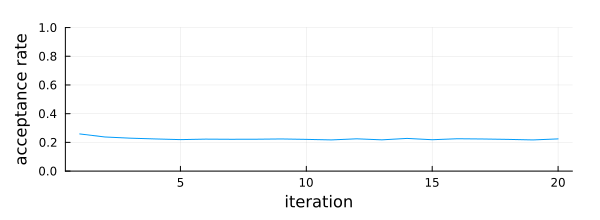

In [9]:
plot(
    acceptrate;
    xlabel = "iteration",
    ylabel = "acceptance rate",
    label = nothing,
    size = (600, 220),
    margin = 5Plots.mm,
    ylims = (0, 1),
)

In [10]:
function plot_histograms_and_logweights(xlabel, hist_vec, lw_vec; title_prefix = "")
    n = length(hist_vec)
    cols = palette(:viridis, max(n, 2))[1:n]
    xs = collect(hist_vec[1].bins[1])

    p1 = plot(
        xs,
        hist_vec[1].values;
        lw = 2,
        color = cols[1],
        xlabel = xlabel,
        ylabel = "counts",
        title = "$(title_prefix) histograms",
        legend = false,
        ylims = (0, maximum(hist_vec[1].values) * 1.2),
    )
    for i in 2:n
        plot!(p1, xs, hist_vec[i].values; lw = 2, color = cols[i])
    end

    p2 = plot(
        xlabel = xlabel,
        ylabel = "-logweight",
        title = "$(title_prefix) -log(weights)",
        legend = false,
    )
    i0 = 1
    for i in 1:n
        plot!(p2, xs, -lw_vec[i].values .+ lw_vec[i].values[i0]; lw = 2, color = cols[i])
    end

    plot(p1, p2; layout = (@layout([a b])), size = (960, 320), margin = 4Plots.mm)
end

plot_histograms_and_logweights (generic function with 1 method)

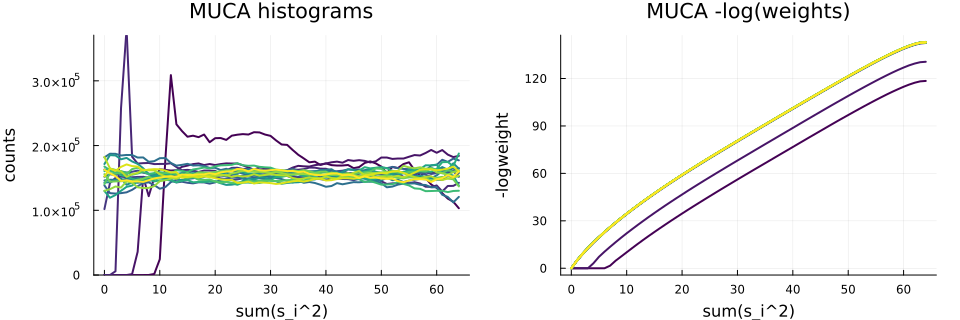

In [11]:
plot_histograms_and_logweights("sum(s_i^2)", histograms, logweights; title_prefix = "MUCA")